In [1]:
import utils
import numpy as np
import pandas as pd
import os
import importlib
import re
from scipy.stats import gaussian_kde

importlib.reload(utils)

import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

pd.set_option('future.no_silent_downcasting', True)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', 20)
#pd.set_option('display.width', 1000)

In [2]:
# Make output folder
output_dir = os.path.join('..','..','plots','behavioural', 'speed-accuracy_trade-off')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
# Preparation
rerun_glob = True
if rerun_glob:
    pilot_analysis = False
    unique_subject_ids = [5, 10, 11, 14]#[802,803,804,805,806,807,808,809,810,811,813,814,815]
    unique_sessions = [2, 3, 4]
    plot_range = [0, 6]

    if pilot_analysis:
        raw_output_path = '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2'
    else:
        raw_output_path = '/Volumes/project/3025011.02/raw/'
    recent_results = utils.analysis_functions.list_files_with_date_and_subject_id(raw_output_path, unique_subject_ids, unique_sessions)

In [4]:
if not recent_results:
    raise Exception('No files found')
print(recent_results)

['/Volumes/project/3025011.02/raw/sub-005/ses-mri02/beh/behavioural_output_sub-005_session-02_skyra_2025-03-14_11-00-23.csv', '/Volumes/project/3025011.02/raw/sub-005/ses-mri03/beh/behavioural_output_sub-005_session-03_skyra_2025-03-21_15-48-02.csv', '/Volumes/project/3025011.02/raw/sub-005/ses-mri04/beh/behavioural_output_sub-005_session-04_skyra_2025-03-28_15-50-17.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri02/beh/behavioural_output_sub-010_session-02_skyra_2025-03-13_11-21-05.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri03/beh/behavioural_output_sub-010_session-03_skyra_2025-03-19_11-41-24.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri04/beh/behavioural_output_sub-010_session-04_skyra_2025-03-25_15-18-37.csv', '/Volumes/project/3025011.02/raw/sub-011/ses-mri02/beh/behavioural_output_sub-011_session-02_skyra_2025-04-04_16-07-03.csv', '/Volumes/project/3025011.02/raw/sub-011/ses-mri03/beh/behavioural_output_sub-011_session-03_skyra_2025-04-11_11-31-46.csv',

### Remove invalid files

In [5]:
# Remove files that contain invalid data
raw_output_path = '/Volumes/project/3025011.02/raw/'
invalid_data = pd.read_csv(f'{raw_output_path}../incomplete_data.csv', delimiter=';')
combinations = {
    f"sub-{row['subject-id']:03}_session-{row['session-number']:02}"
    for _, row in invalid_data[invalid_data['datatype'] == 'beh'].iterrows()
}
print(f'These participants will be excluded: {combinations}')

patterns = [re.compile(re.escape(combo)) for combo in combinations]
# Filter the list: remove any string that contains one of the combinations
recent_results = [
    item for item in recent_results
    if not any(pattern.search(item) for pattern in patterns)
]
print(recent_results)

These participants will be excluded: {'sub-003_session-03'}
['/Volumes/project/3025011.02/raw/sub-005/ses-mri02/beh/behavioural_output_sub-005_session-02_skyra_2025-03-14_11-00-23.csv', '/Volumes/project/3025011.02/raw/sub-005/ses-mri03/beh/behavioural_output_sub-005_session-03_skyra_2025-03-21_15-48-02.csv', '/Volumes/project/3025011.02/raw/sub-005/ses-mri04/beh/behavioural_output_sub-005_session-04_skyra_2025-03-28_15-50-17.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri02/beh/behavioural_output_sub-010_session-02_skyra_2025-03-13_11-21-05.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri03/beh/behavioural_output_sub-010_session-03_skyra_2025-03-19_11-41-24.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri04/beh/behavioural_output_sub-010_session-04_skyra_2025-03-25_15-18-37.csv', '/Volumes/project/3025011.02/raw/sub-011/ses-mri02/beh/behavioural_output_sub-011_session-02_skyra_2025-04-04_16-07-03.csv', '/Volumes/project/3025011.02/raw/sub-011/ses-mri03/beh/behaviour

In [6]:
combined_results_dataframe = utils.analysis_functions.combine_result_files(recent_results)
if pilot_analysis:
    combined_results_dataframe.rename(columns={'iti': 'trial_duration'}, inplace=True)
    combined_results_dataframe['stimuli_type'] = combined_results_dataframe['stimuli_type'].replace(3, 2)
print(combined_results_dataframe)

      trial  emotional_cue_time response objectively_correct  \
0         0        1.741947e+09     down                Even   
1         1        1.741947e+09       up                Even   
2         2        1.741947e+09       up                Even   
3         3        1.741947e+09     down                Even   
4         4        1.741947e+09     down                Even   
5         5        1.741947e+09     down                Even   
6         6        1.741947e+09       up                Even   
7         7        1.741947e+09     down                Even   
8         8        1.741947e+09       up               False   
9         9        1.741947e+09       up                True   
10       10        1.741947e+09     down               False   
11       11        1.741947e+09       up               False   
12       12        1.741947e+09       up               False   
13       13        1.741947e+09       up                True   
14       14        1.741947e+09     down

# Flip results if joystick orientation was incorrect
Specifically, switch the response and probability

In [7]:
# List of subject_session combinations to update
match_list = ['sub-004_session-04']

# Create a new column that combines subject_id and session in the same format as the list.
combined_results_dataframe['sub_session'] = combined_results_dataframe['subject_id'] + '_' + combined_results_dataframe['session']

# Create a mask for rows that match any of the combinations in match_list.
mask = combined_results_dataframe['sub_session'].isin(match_list)

# For 'probability_condition', swap 80 with 20 and vice versa.
combined_results_dataframe.loc[mask, 'probability_condition'] = (
    combined_results_dataframe.loc[mask, 'probability_condition']
    .replace({80: 20, 20: 80})
)

# For 'response', swap 'up' with 'down' and vice versa.
combined_results_dataframe.loc[mask, 'response'] = (
    combined_results_dataframe.loc[mask, 'response']
    .replace({'up': 'down', 'down': 'up'})
)

# Optionally, drop the helper column
combined_results_dataframe.drop(columns='sub_session', inplace=True)

print(combined_results_dataframe)

      trial  emotional_cue_time response objectively_correct  \
0         0        1.741947e+09     down                Even   
1         1        1.741947e+09       up                Even   
2         2        1.741947e+09       up                Even   
3         3        1.741947e+09     down                Even   
4         4        1.741947e+09     down                Even   
5         5        1.741947e+09     down                Even   
6         6        1.741947e+09       up                Even   
7         7        1.741947e+09     down                Even   
8         8        1.741947e+09       up               False   
9         9        1.741947e+09       up                True   
10       10        1.741947e+09     down               False   
11       11        1.741947e+09       up               False   
12       12        1.741947e+09       up               False   
13       13        1.741947e+09       up                True   
14       14        1.741947e+09     down

# Analysis
First, we'll look at the reaction time. A plot with all the RT's and average will do.
Second we will look at the percentage of correct answers.
Lastly, we will be looking at a win-stay lose shift to see when behaviour stabilises after a shift in reward contingency.

In [8]:
# Count amount of subplots necessary based on subject_id's and sessions
## Finds unique values
unique_subject_ids = combined_results_dataframe['subject_id'].unique()
unique_sessions = combined_results_dataframe['session'].unique()

## Calculates the number of subplots needed
n_rows = len(unique_subject_ids)
n_cols = len(unique_sessions)
n_subplots = len(unique_sessions) * len(unique_subject_ids)

### Make additional columns for congruency, valence, WSLS and volatility

In [9]:
combined_results_dataframe['congruency'] = combined_results_dataframe.apply(utils.analysis_functions.check_congruency, axis=1)
print(combined_results_dataframe[['stimuli_type','probability_condition','congruency']])

      stimuli_type  probability_condition   congruency
0                1                     50    undefined
1                1                     50    undefined
2                1                     50    undefined
3                2                     50    undefined
4                2                     50    undefined
5                2                     50    undefined
6                2                     50    undefined
7                1                     50    undefined
8                1                     20  incongruent
9                2                     80  incongruent
10               2                     80  incongruent
11               1                     20  incongruent
12               1                     20  incongruent
13               2                     80  incongruent
14               1                     20  incongruent
15               1                     20  incongruent
16               2                     80  incongruent
17        

In [10]:
combined_results_dataframe['valence'] = combined_results_dataframe.apply(utils.analysis_functions.check_valence, axis=1)
print(combined_results_dataframe[['stimuli_type','valence']])

      stimuli_type valence
0                1   angry
1                1   angry
2                1   angry
3                2   happy
4                2   happy
5                2   happy
6                2   happy
7                1   angry
8                1   angry
9                2   happy
10               2   happy
11               1   angry
12               1   angry
13               2   happy
14               1   angry
15               1   angry
16               2   happy
17               2   happy
18               1   angry
19               1   angry
20               2   happy
21               2   happy
22               2   happy
23               1   angry
24               1   angry
25               2   happy
26               1   angry
27               1   angry
28               2   happy
29               2   happy
30               2   happy
31               2   happy
32               1   angry
33               1   angry
34               2   happy
35               1   angry
3

In [11]:
# Turns the objective values into boolean ones
mapping = {'True': 1, 'False': 0, 'Even': 0, 'Late': 0}
#pd.options.display.max_rows = None

combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct'].replace(mapping)
combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct_boolean'].astype('int')

In [12]:
# Add volatility column
combined_results_dataframe = combined_results_dataframe[combined_results_dataframe['probability_condition'] != 50]
combined_results_dataframe = combined_results_dataframe.groupby('stimuli_type', group_keys=False).apply(lambda x: utils.analysis_functions.check_volatility(x))
combined_results_dataframe = combined_results_dataframe.sort_values(by=['subject_id','session','stimuli_type','trial'], ascending=[True, True, True, True])
print(combined_results_dataframe)

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_1553/2827216585.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  combined_results_dataframe = combined_results_dataframe.groupby('stimuli_type', group_keys=False).apply(lambda x: utils.analysis_functions.check_volatility(x))


      trial  emotional_cue_time response objectively_correct  \
0         8        1.741947e+09       up               False   
1        11        1.741947e+09       up               False   
2        12        1.741947e+09       up               False   
3        14        1.741947e+09     down                True   
4        15        1.741947e+09     down                True   
5        18        1.741947e+09     down                True   
6        19        1.741947e+09       up               False   
7        23        1.741947e+09     down                True   
8        24        1.741947e+09     down                True   
9        26        1.741947e+09     down                True   
10       27        1.741947e+09     down                True   
11       32        1.741947e+09     down                True   
12       33        1.741947e+09     down                True   
13       35        1.741947e+09     down                True   
14       36        1.741947e+09     down

In [13]:
# Filter out very short RT's

# Plot the relation between speed and accuracy
Quantile probability function

In [14]:
quadratic_trend = False

In [15]:
# suppose your original DataFrame is called df
summary = (
    combined_results_dataframe
    .groupby(['subject_id', 'session', 'congruency'])
    .agg(
        mean_reaction_time=('RT_s', 'mean'),
        mean_performance=('objectively_correct_boolean', 'mean')
    )
    .reset_index()
)

print(summary)

   subject_id     session   congruency  mean_reaction_time  mean_performance
0     sub-005  session-02    congruent            0.664637          0.770833
1     sub-005  session-02  incongruent            0.680667          0.734568
2     sub-005  session-03    congruent            0.683968          0.773529
3     sub-005  session-03  incongruent            0.688644          0.737500
4     sub-005  session-04    congruent            0.617006          0.692073
5     sub-005  session-04  incongruent            0.622196          0.792169
6     sub-010  session-02    congruent            0.655736          0.755747
7     sub-010  session-02  incongruent            0.694939          0.711538
8     sub-010  session-03    congruent            0.677188          0.767647
9     sub-010  session-03  incongruent            0.673750          0.793750
10    sub-010  session-04    congruent            0.653175          0.798193
11    sub-010  session-04  incongruent            0.653384          0.780488

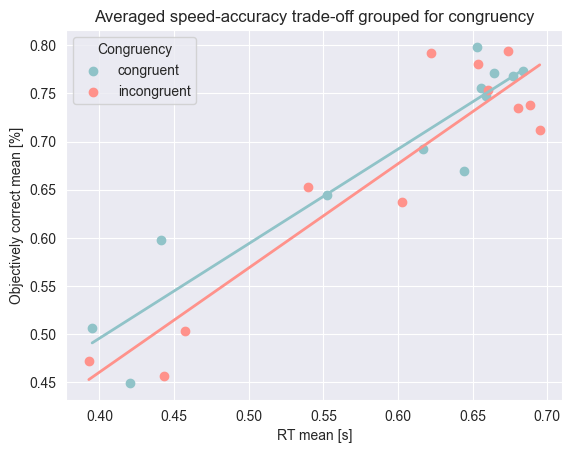

In [16]:
x_col = 'mean_reaction_time'
y_col = 'mean_performance'
group_col = 'congruency'

# Define colours for each group
colour_map = {
    'congruent':   '#90C3C8',
    'incongruent': '#FF928B',
}

fig, ax = plt.subplots()

for cong, group in summary.groupby(group_col):
    x = group[x_col].values
    y = group[y_col].values
    col = colour_map.get(cong, 'gray')

    # Only the scatter gets a legend label
    ax.scatter(x, y, color=col, label=cong)

    # Fit a trendline
    if quadratic_trend:
        a, b, c = np.polyfit(x, y, deg=2)
        x_smooth = np.linspace(x.min(), x.max(), 200)
        y_smooth = a*x_smooth**2 + b*x_smooth + c

        ax.plot(x_smooth, y_smooth, color=col, linewidth=2, label='_nolegend_')
    else:
        m, c = np.polyfit(x, y, deg=1)
        x_line = np.array([x.min(), x.max()])
        y_line = m*x_line + c

        ax.plot(x_line, y_line, color=col, linewidth=2, label='_nolegend_')

ax.set_xlabel('RT mean [s]')
ax.set_ylabel('Objectively correct mean [%]')
plot_name = 'Averaged speed-accuracy trade-off grouped for congruency'
ax.set_title(plot_name)
ax.legend(title='Congruency')
os.makedirs(output_dir, exist_ok=True)
fig.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

In [17]:
# suppose your original DataFrame is called df
summary = (
    combined_results_dataframe
    .groupby(['subject_id', 'session', 'volatility'])
    .agg(
        mean_reaction_time=('RT_s', 'mean'),
        mean_performance=('objectively_correct_boolean', 'mean')
    )
    .reset_index()
)

print(summary)

   subject_id     session volatility  mean_reaction_time  mean_performance
0     sub-005  session-02     stable            0.661357          0.840659
1     sub-005  session-02   volatile            0.686216          0.645270
2     sub-005  session-03     stable            0.684610          0.779570
3     sub-005  session-03   volatile            0.688333          0.725694
4     sub-005  session-04     stable            0.622255          0.785326
5     sub-005  session-04   volatile            0.616291          0.688356
6     sub-010  session-02     stable            0.673690          0.733696
7     sub-010  session-02   volatile            0.674997          0.736301
8     sub-010  session-03     stable            0.679926          0.788462
9     sub-010  session-03   volatile            0.670105          0.770270
10    sub-010  session-04     stable            0.658221          0.847368
11    sub-010  session-04   volatile            0.646571          0.710714
12    sub-011  session-02

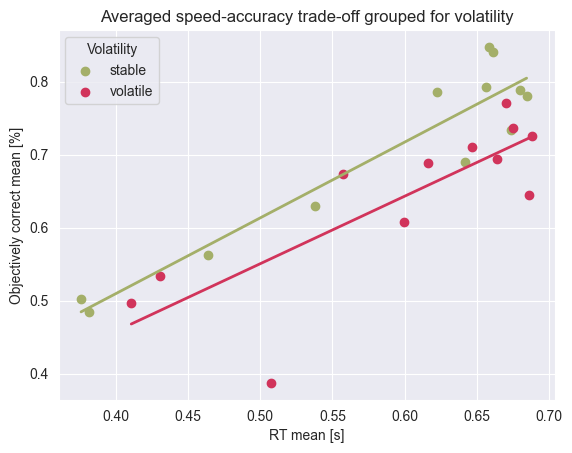

In [18]:
x_col = 'mean_reaction_time'
y_col = 'mean_performance'
group_col = 'volatility'

# Define colours for each group
colour_map = {
    'stable':   '#A4AF69',
    'volatile': '#D1345B',
}

fig, ax = plt.subplots()

for cong, group in summary.groupby(group_col):
    x = group[x_col].values
    y = group[y_col].values
    col = colour_map.get(cong, 'gray')

    # Only the scatter gets a legend label
    ax.scatter(x, y, color=col, label=cong)

    # Fit a trendline
    if quadratic_trend:
        a, b, c = np.polyfit(x, y, deg=2)
        x_smooth = np.linspace(x.min(), x.max(), 200)
        y_smooth = a*x_smooth**2 + b*x_smooth + c

        ax.plot(x_smooth, y_smooth, color=col, linewidth=2, label='_nolegend_')
    else:
        m, c = np.polyfit(x, y, deg=1)
        x_line = np.array([x.min(), x.max()])
        y_line = m*x_line + c

        ax.plot(x_line, y_line, color=col, linewidth=2, label='_nolegend_')

ax.set_xlabel('RT mean [s]')
ax.set_ylabel('Objectively correct mean [%]')
plot_name = 'Averaged speed-accuracy trade-off grouped for volatility'
ax.set_title(plot_name)
ax.legend(title='Volatility')
os.makedirs(output_dir, exist_ok=True)
fig.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

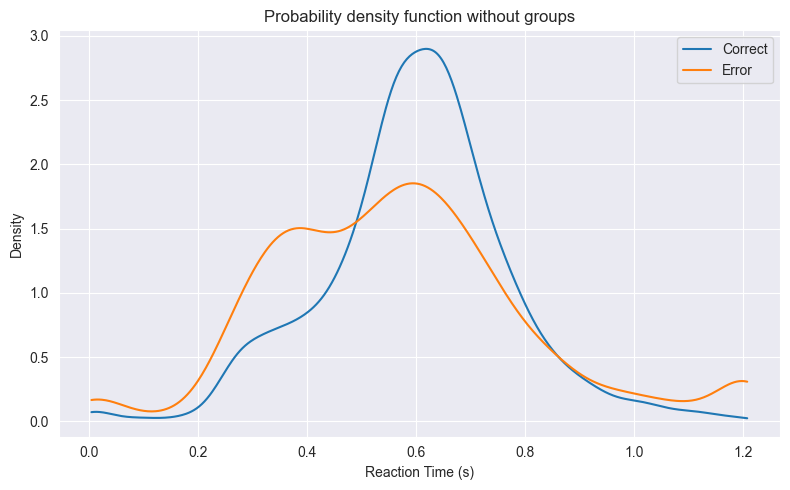

In [19]:
# assume `df` is your DataFrame
# split RTs by correctness
rts_correct = combined_results_dataframe.loc[combined_results_dataframe['objectively_correct_boolean'] == 1, 'RT_s']
rts_error   = combined_results_dataframe.loc[combined_results_dataframe['objectively_correct_boolean'] == 0, 'RT_s']

# compute KDEs
kde_correct = gaussian_kde(rts_correct)
kde_error   = gaussian_kde(rts_error)

# choose a common x‐axis range
xmin, xmax = combined_results_dataframe['RT_s'].min(), combined_results_dataframe['RT_s'].max()
x_vals = np.linspace(xmin, xmax, 500)

# plot both densities
plt.figure(figsize=(8, 5))
plt.plot(x_vals, kde_correct(x_vals), label='Correct')
plt.plot(x_vals, kde_error(  x_vals), label='Error')
plt.xlabel('Reaction Time (s)')
plt.ylabel('Density')
plot_name = 'Probability density function without groups'
plt.title(plot_name)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

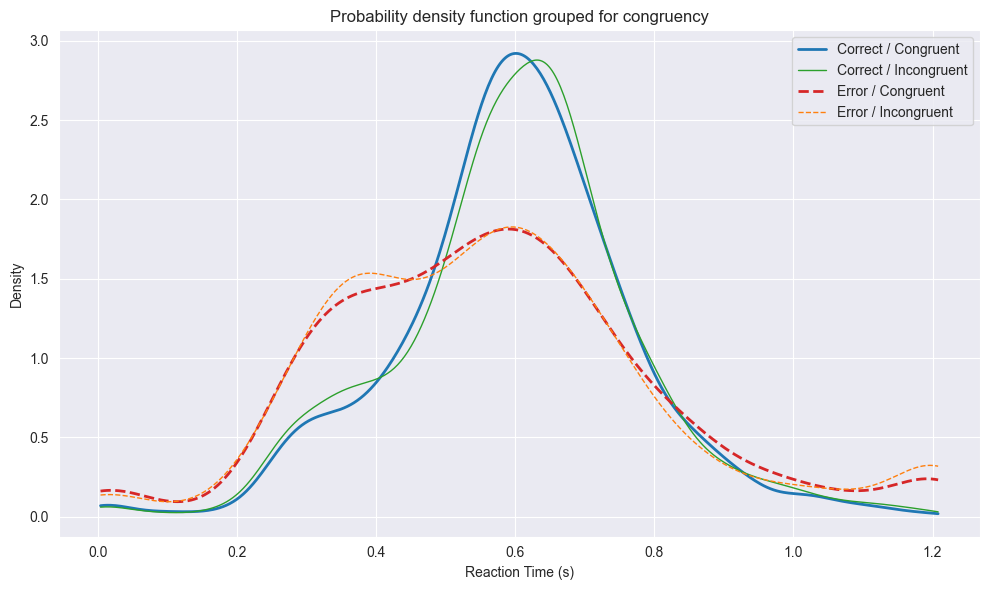

In [20]:
# define your two factors
correctness_levels = {
    1: 'Correct',
    0: 'Error'
}
congruency_levels = ['congruent', 'incongruent']

# Define your color map for (correctness, congruency)
color_map = {
    (1, 'congruent'):   'tab:blue',
    (1, 'incongruent'): 'tab:green',
    (0, 'congruent'):   'tab:red',
    (0, 'incongruent'): 'tab:orange'
}

# Prepare x-axis
xmin, xmax = combined_results_dataframe['RT_s'].min(), combined_results_dataframe['RT_s'].max()
x_vals = np.linspace(xmin, xmax, 500)

plt.figure(figsize=(10, 6))

# Loop through each combination
for obj_val, obj_label in [(1, 'Correct'), (0, 'Error')]:
    for cong in ['congruent', 'incongruent']:
        subset = combined_results_dataframe[
            (combined_results_dataframe['objectively_correct_boolean'] == obj_val) &
            (combined_results_dataframe['congruency'] == cong)
        ]['RT_s']
        if len(subset) < 2:
            continue

        kde = gaussian_kde(subset)
        label = f"{obj_label} / {cong.capitalize()}"
        c = color_map[(obj_val, cong)]

        plt.plot(x_vals, kde(x_vals),
                 label=label,
                 color=c,
                 linestyle='-' if obj_val == 1 else '--',
                 linewidth=2 if cong == 'congruent' else 1)

# finalize
plt.xlabel('Reaction Time (s)')
plt.ylabel('Density')
plot_name = 'Probability density function grouped for congruency'
plt.title(plot_name)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

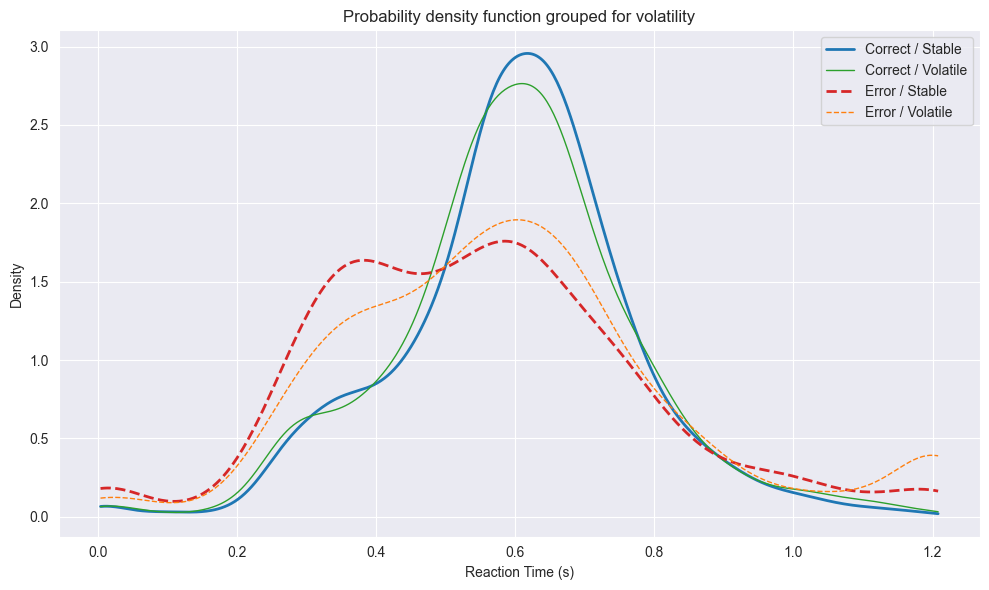

In [21]:
# define your two factors
correctness_levels = {
    1: 'Correct',
    0: 'Error'
}
congruency_levels = ['stable', 'volatile']

# Define your color map for (correctness, congruency)
color_map = {
    (1, 'stable'):   'tab:blue',
    (1, 'volatile'): 'tab:green',
    (0, 'stable'):   'tab:red',
    (0, 'volatile'): 'tab:orange'
}

# Prepare x-axis
xmin, xmax = combined_results_dataframe['RT_s'].min(), combined_results_dataframe['RT_s'].max()
x_vals = np.linspace(xmin, xmax, 500)

plt.figure(figsize=(10, 6))

# Loop through each combination
for obj_val, obj_label in [(1, 'Correct'), (0, 'Error')]:
    for volatility in ['stable', 'volatile']:
        subset = combined_results_dataframe[
            (combined_results_dataframe['objectively_correct_boolean'] == obj_val) &
            (combined_results_dataframe['volatility'] == volatility)
        ]['RT_s']
        if len(subset) < 2:
            continue

        kde = gaussian_kde(subset)
        label = f"{obj_label} / {volatility.capitalize()}"
        c = color_map[(obj_val, volatility)]

        plt.plot(x_vals, kde(x_vals),
                 label=label,
                 color=c,
                 linestyle='-' if obj_val == 1 else '--',
                 linewidth=2 if volatility == 'stable' else 1)

# finalize
plt.xlabel('Reaction Time (s)')
plt.ylabel('Density')
plot_name = 'Probability density function grouped for volatility'
plt.title(plot_name)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

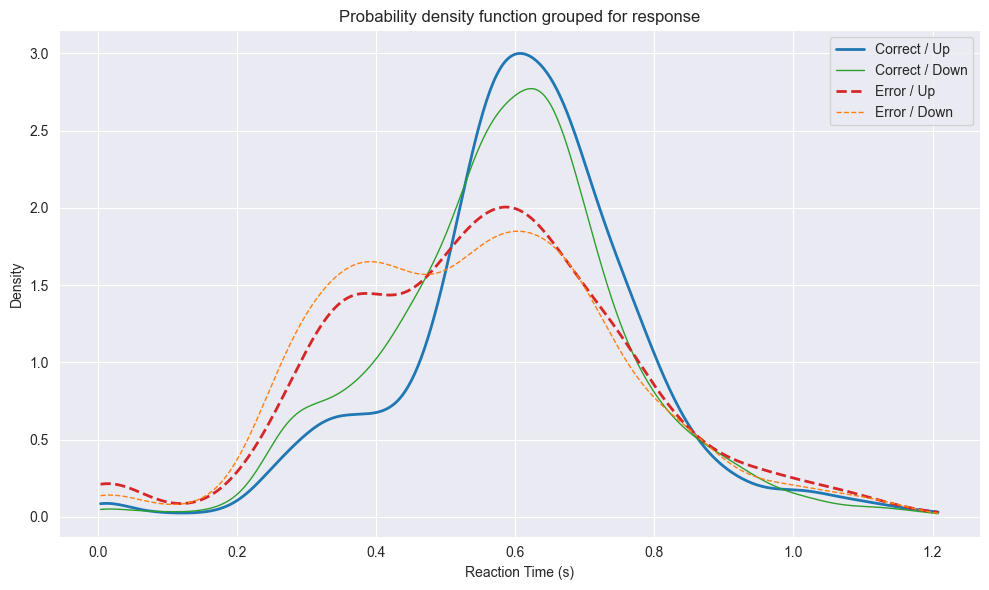

In [22]:
# define your two factors
correctness_levels = {
    1: 'Correct',
    0: 'Error'
}
congruency_levels = ['up', 'down']

# Define your color map for (correctness, congruency)
color_map = {
    (1, 'up'):   'tab:blue',
    (1, 'down'): 'tab:green',
    (0, 'up'):   'tab:red',
    (0, 'down'): 'tab:orange'
}

# Prepare x-axis
xmin, xmax = combined_results_dataframe['RT_s'].min(), combined_results_dataframe['RT_s'].max()
x_vals = np.linspace(xmin, xmax, 500)

plt.figure(figsize=(10, 6))

# Loop through each combination
for obj_val, obj_label in [(1, 'Correct'), (0, 'Error')]:
    for response_direction in ['up', 'down']:
        subset = combined_results_dataframe[
            (combined_results_dataframe['objectively_correct_boolean'] == obj_val) &
            (combined_results_dataframe['response'] == response_direction)
        ]['RT_s']
        if len(subset) < 2:
            continue

        kde = gaussian_kde(subset)
        label = f"{obj_label} / {response_direction.capitalize()}"
        c = color_map[(obj_val, response_direction)]

        plt.plot(x_vals, kde(x_vals),
                 label=label,
                 color=c,
                 linestyle='-' if obj_val == 1 else '--',
                 linewidth=2 if response_direction == 'up' else 1)

# finalize
plt.xlabel('Reaction Time (s)')
plt.ylabel('Density')
plot_name = 'Probability density function grouped for response'
plt.title(plot_name)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()